In [3]:
# Loaded All Trained Models
import joblib

log_reg = joblib.load("../models/logistic_regression.pkl")
rf = joblib.load("../models/randum_forest.pkl")
xgb = joblib.load("../models/xgboost.pkl")

x_test = joblib.load("../data/processed/x_test.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

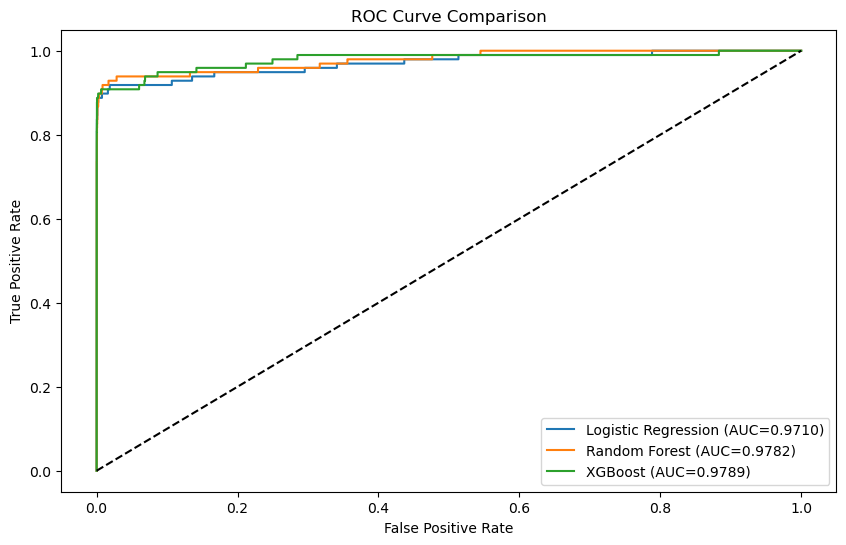

In [4]:
# ROC Curve for All Models
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_lr = log_reg.predict_proba(x_test)[:, 1]
y_pred_rf = rf.predict_proba(x_test)[:, 1]
y_pred_xgb = xgb.predict_proba(x_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)

plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc(fpr_rf, tpr_rf):.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc(fpr_xgb, tpr_xgb):.4f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

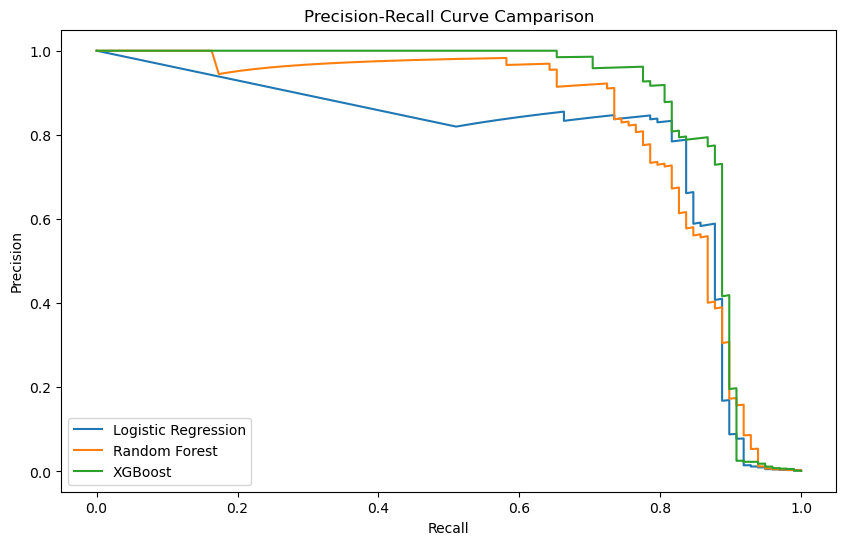

In [5]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_xgb)

plt.figure(figsize =(10, 6))

plt.plot(rec_lr, prec_lr, label="Logistic Regression")
plt.plot(rec_rf, prec_rf, label="Random Forest")
plt.plot(rec_xgb, prec_xgb, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Camparison")
plt.legend()
plt.show()

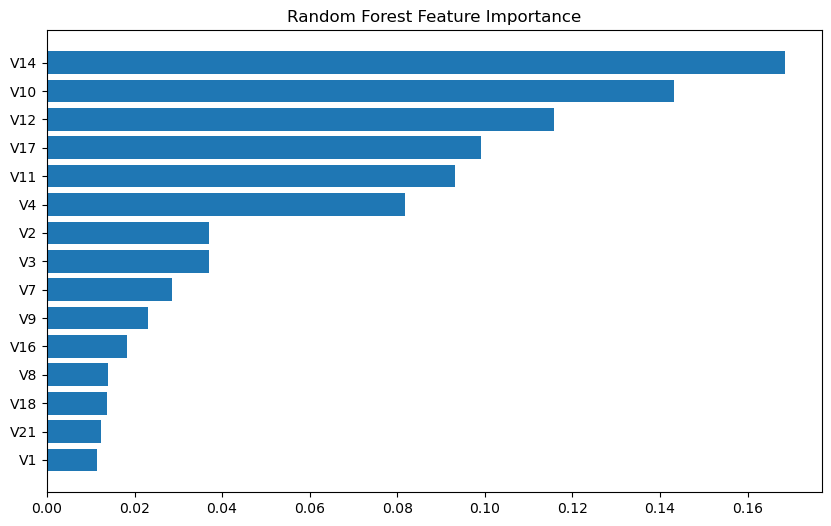

In [6]:
# Feature Importance (Random Forest)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
indices =np.argsort(importance)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importance[indices], align='center')
plt.yticks(range(len(indices)), x_test.columns[indices])
plt.title("Random Forest Feature Importance")
plt.show()

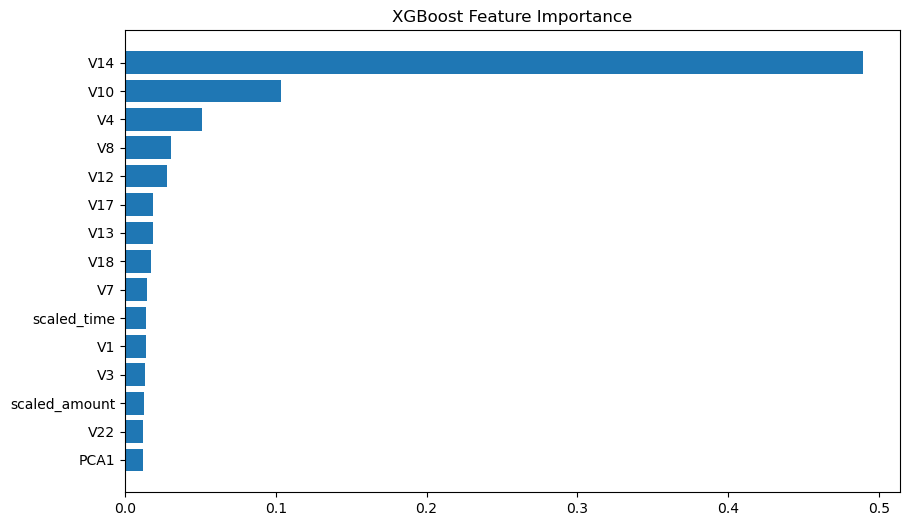

In [7]:
# Feature Importance (XGBoost)
xgb_importance = xgb.feature_importances_
idx = np.argsort(xgb_importance)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(idx)), xgb_importance[idx])
plt.yticks(range(len(idx)), x_test.columns[idx])
plt.title("XGBoost Feature Importance")
plt.show()

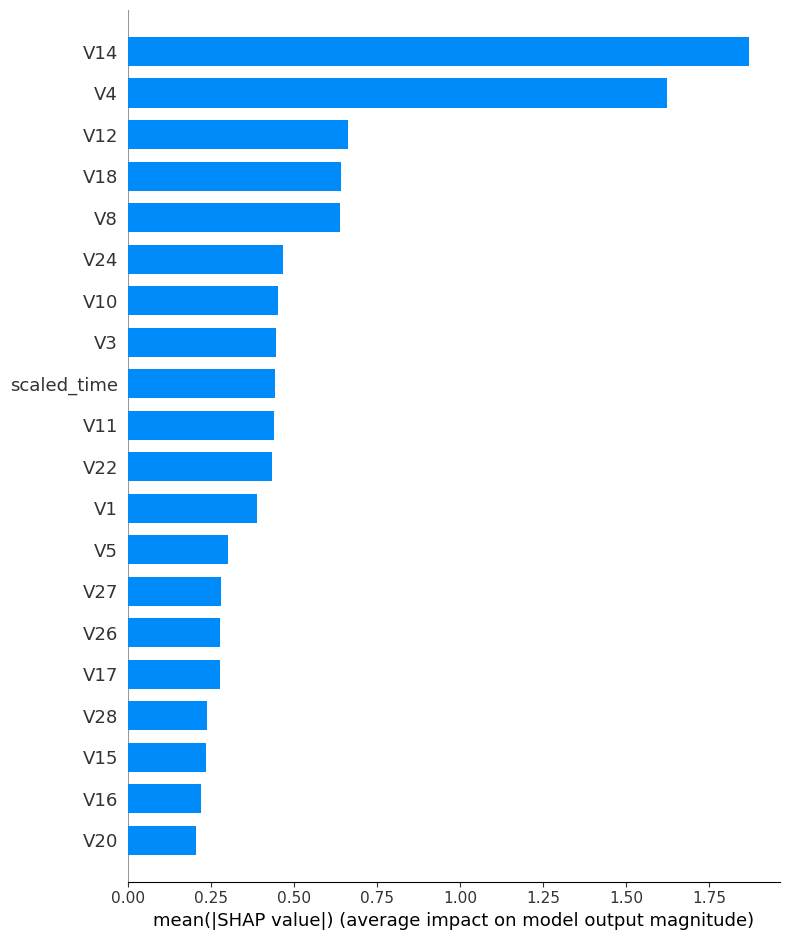

In [9]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test, plot_type="bar")

In [10]:
# Fraud Case Deep Analysis (SHAP Force Plot)
shap.initjs()

i = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    x_test.iloc[i],
)

In [11]:
df = pd.read_csv("../data/processed/creditcard_preprocessed.csv")

In [12]:
x = df.drop("Class", axis=1)
y = df["Class"]

print(x.shape)
print(y.shape)

(284807, 32)
(284807,)


In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42, stratify=y)

In [14]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)
rf_proba = rf.predict_proba(x_test)[:, 1]

print("=== Random Forest Report ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9598101234022027


In [18]:
# Hyperparameter Tuning for Random Forest (GridSearchCV)
from sklearn.model_selection import GridSearchCV

grid_params = {
    "n_estimators": [80, 100, 120],
    "max_depth": [10, 12, 15],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    grid_params,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=3
)

rf_grid.fit(x_train, y_train)

print("Best Rf Params:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
Best Rf Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8247163406674081


In [19]:
# Train XGBoost Model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    scale_pos_weight=10
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)
xgb_proba = xgb.predict_proba(x_test)[:, 1]

print("=== XGBoost Report ===")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

=== XGBoost Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9771727996910639


In [20]:
# XGBoost Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", scale_pos_weight=10),
    xgb_params,
    n_iter=10,
    scoring="f1",
    n_jobs=-1,
    cv=3,
    random_state=42
)

xgb_search.fit(x_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best Score:", xgb_search.best_score_)

Best XGB Params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best Score: 0.8618797715322125


In [21]:
# Train LightGBM Model
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced"
)

lgbm.fit(x_train, y_train)

lgbm_pred = lgbm.predict(x_test)
lgbm_proba = lgbm.predict_proba(x_test)[:, 1]

print("=== LightGBM Report ===")
print(classification_report(y_test, lgbm_pred))
print("ROC-AUC:", roc_auc_score(y_test, lgbm_proba))

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
=== LightGBM Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9800636032409588


In [22]:
# Compare All Models
import pandas as pd

results = {
    "Mofel": ["Random Forest", "XGBoost", "LightGBM"],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, lgbm_proba)
    ]
}

df_results = pd.DataFrame(results)
df_results.sort_values(by="ROC-AUC", ascending=False)

,Mofel,ROC-AUC
2,LightGBM,0.980064
1,XGBoost,0.977173
0,Random Forest,0.959810


In [23]:
# Save the Best Model
import joblib

best_model = xgb

joblib.dump(best_model, "best_fraud_model.pkl")

print("Model saved as best_fraud_model.pkl")

Model saved as best_fraud_model.pkl
